In [1]:
import numpy as np
from astropy.io import fits
from mylib.phot_functions import source_mask, back2d
from astropy.convolution import Gaussian2DKernel, Tophat2DKernel
from convenience_functions5 import show_image

file = './20211015/0373_SO2021B-203_1510.fits'
hdul = fits.open(file)
hdul.info()
img = hdul[0].data
hdr = hdul[0].header
hdul.close()

flat = './20211015/master_flat5.fits'
hdul = fits.open(flat)
hdul.info()
coverage_mask = hdul[1].data
coverage_mask.dtype = bool
hdul.close()


Filename: ./20211015/0373_SO2021B-203_1510.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   (1548, 1548)   float32   
Filename: ./20211015/master_flat5.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     131   (1548, 1548)   float32   
  1  MASK          1 ImageHDU         8   (1548, 1548)   uint8   


In [1]:
from os import path, remove
from shutil import copytree
from ccdproc import ImageFileCollection
import re
import glob
from dataprocessing_functions import acquisition_remove

In [2]:
folder = './20241204/' 
summary_keywords=['obstype','object','airmass','exptime']
ifc = ImageFileCollection(
    folder, keywords=summary_keywords, ext=0, 
    glob_exclude='*master*.fits', glob_include='*.fits')

acquisition_remove(folder)


In [ ]:
dataset = './20241204/' 
keyword_filters=["object = ac*", "object = foc*"]
filename_filters=["*test*.fits","gp*.fits","*acq*.fits","*focus*.fits"]

ifc_keywords = ['obstype','object','airmass','exptime','filter','filter1','filter2']

#.Initializing keywords from a coma-separated string (should be a list)
if isinstance(keyword_filters,str):
    keyword_filters = keyword_filters.split(',')
if isinstance(filename_filters, str):
    filename_filters = filename_filters.split(',')

#.Processing keyword filters expressions
demanded_keywords = []
if keyword_filters is not None:
    kwd_dict = {}
    for string_expr in keyword_filters:

        #.Splitting expression using common operators
        split_expr = re.split(r'[+<>=!?&|\s]+', string_expr)
        demanded_keywords.append(split_expr[0])
        split_expr[1] = split_expr[1].replace('*','.*',2)
        if split_expr[0].lower() in kwd_dict:
            kwd_dict[split_expr[0].lower()] += "|("+split_expr[1]+")"
        else:
            kwd_dict[split_expr[0].lower()] = "\s("+split_expr[1]+")"

#.If input dataset is a folder, expand it into a ImageFileCollection
ifc_keywords = list(set(ifc_keywords+demanded_keywords))
if isinstance(dataset,str): 
    ifc = ImageFileCollection(dataset, ext=0, keywords=ifc_keywords,
        glob_exclude="*master*.fits, bpm*.fits", glob_include="*.fits")
    
#.Otherwise the input dataset is already a ImageFileCollection
else: 
    ifc = dataset
    ifc.keywords += demanded_keywords

#.Backing up RAW data before any file deletion
folder = ifc.location
if not path.isdir(path.join(folder,'raw')):
    copytree(folder, path.join(folder,'raw'), dirs_exist_ok=False)

#.Filtering images by keyword selection
if keyword_filters is not None:

    keyword_filtered = ifc.files_filtered(**kwd_dict, regex_match=True, include_path=True)

else: keyword_filtered = []

#.Filtering images by filename selection
if filename_filters is not None:

    filename_filtered = []
    for string_expr in filename_filters[0:1]:
        filename_filtered += glob.glob(path.join(folder,string_expr), recursive=False)

else: filename_filtered = []

#.Gahtering filtered images and deleting
table = ifc.summary
file_list = ifc.files_filtered(include_path=True)

remove_list = keyword_filtered + filename_filtered
remove_index = []

for file in remove_list:
    #..saving removed image table index 
    remove_index.append(file_list.index(file))
    #..deleting image
    try: remove(file)
    except OSError: pass

#.Logging removed images table to disk
if len(remove_index) > 0:
    table[remove_index].write('removed_images.dat', 
                              format='ascii.fixed_width', 
                              delimiter=' ', overwrite=True)

ifc.refresh()


In [3]:
ifc.summary.pprint_all()

           file           airmass      filter2      filter obstype exptime      object             filter1         
------------------------- ------- ----------------- ------ ------- ------- --------------- ------------------------
SO2024B-101_0412.099.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0029 SAM I-k-c-3x3
SO2024B-101_0412.100.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0029 SAM I-k-c-3x3
SO2024B-101_0412.101.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0027 SAM V-k-c-3x3
SO2024B-101_0412.102.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0027 SAM V-k-c-3x3
SO2024B-101_0412.103.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0026 SAM B-k-c-3x3
SO2024B-101_0412.104.fits    1.37 s9999 unavailable     --  OBJECT    30.0              K3      s0026 SAM B-k-c-3x3
SO2024B-101_0412.105.fits    1.37 s9999 unavailable     --  OBJECT   400

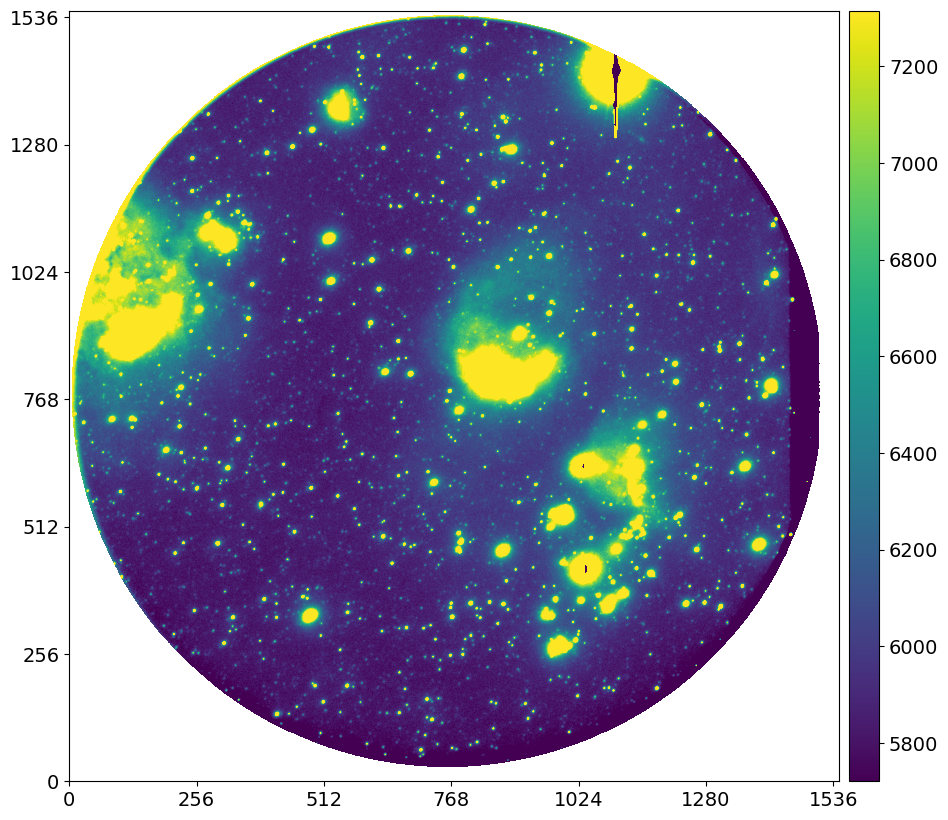

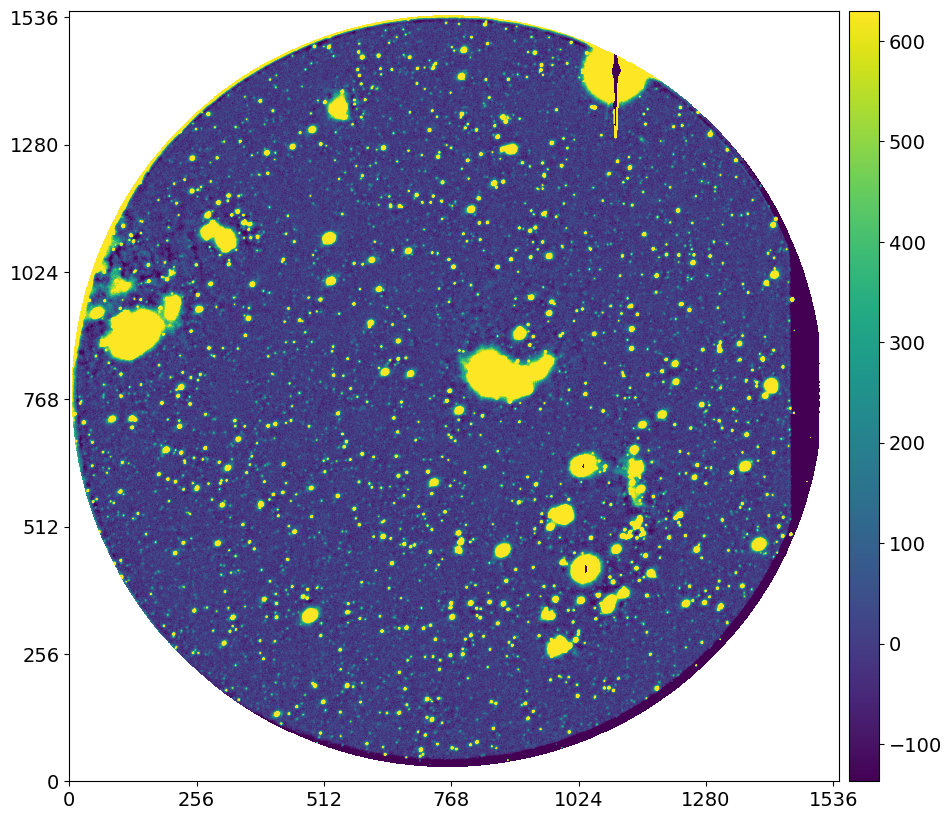

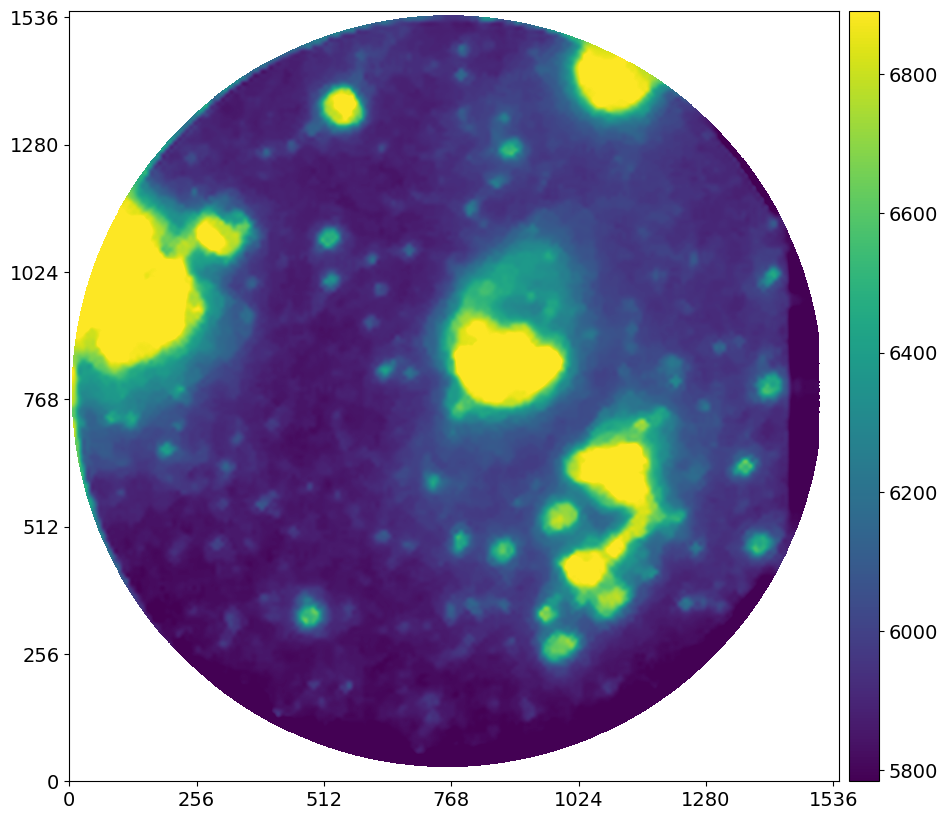

In [5]:
# kernel = Gaussian2DKernel(hdr['FWHM']/2.355)
# kernel = Tophat2DKernel(hdr['FWHM']/2.355)
kernel = None
obj_mask = source_mask(img, kernel=kernel, sigma_upper=8, sigma_lower=4, grow=2).mask

back = back2d(img, hdr, mesh_size=2, median_filter=3,
              mask=obj_mask, coverage_mask=coverage_mask)

show_image(img, percl=95)
show_image(back[1].data, percl=95)
show_image(back[2].data, percl=95)
# show_image(back[3].data, percl=95)